In [27]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, gaussian_kde
import pickle
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import cmasher as cmr
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [28]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [29]:
def reduce_angle(x, y, axis = 1):
    dp = np.sum(x * y, axis = 1)
    xlen = np.sqrt(np.sum(x**2, axis = 1))
    ylen = np.sqrt(np.sum(y**2, axis = 1))
    ang = np.arccos(np.clip((dp/(xlen*ylen)), -1,1))
    return dp, ang

In [30]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [31]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(os.path.join('c:\\',*os.getcwd().split('\\')[1:-1], v1_xs_file))
#v1_scores = pd.read_pickle(os.path.join('/',*os.getcwd().split('/')[:-1], v1_xs_file))
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)

In [32]:
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [33]:
param_bounds = {
    "fts": [0, 0],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [34]:
optimized_model_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'optimization_fts_off.pkl')
with open(optimized_model_file, 'rb') as f:
    optimized_model = pickle.load(f)

In [35]:
model = SGCCircuit(param_bounds, identify=False)

In [36]:
model.load_saved_parameters(optimized_model['final_epoch_params'])

In [37]:
loss_decay = optimized_model['loss_decay']
last_epoch = loss_decay[-1]
lsi = np.argsort(last_epoch)
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 130, loss = 0.083984375


In [38]:
R = model.predict(X).numpy()

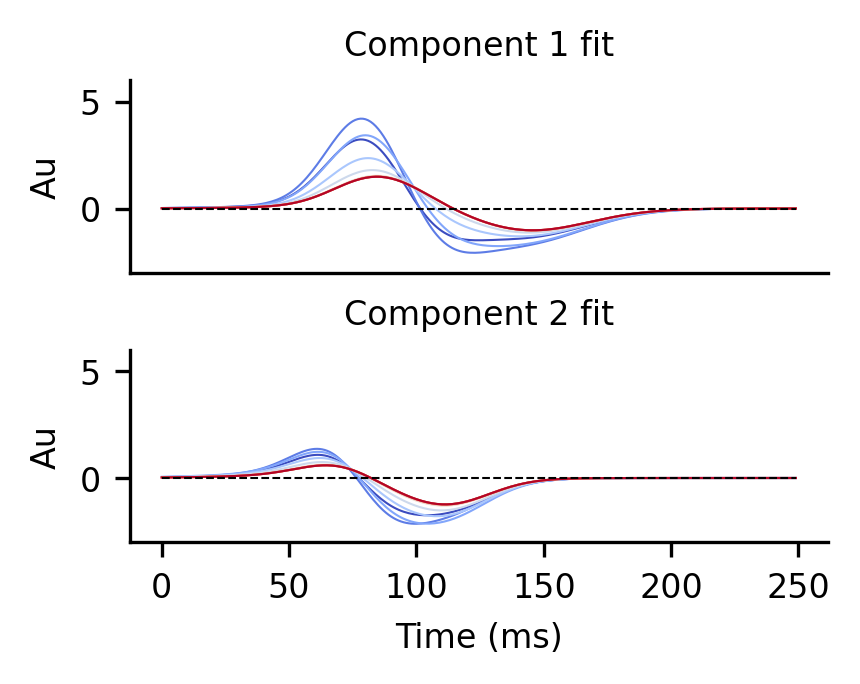

In [39]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(2, figsize = (3,2))

ax[0].plot(R[:,0].mean(0).T, linewidth = linewidth)
ax[0].set_title("Component 1 fit", fontsize = fontsize)
ax[0].set_xticks([])

ax[1].plot(R[:,1].mean(0).T, linewidth = linewidth)
ax[1].set_title('Component 2 fit', fontsize = fontsize)
for i in range(2):
    ax[i].set_ylabel("Au", fontsize = fontsize)
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
ax[0].set_ylim(-3,6)
ax[1].set_ylim(-3,6)
ax[1].set_xlabel("Time (ms)", fontsize = fontsize)
fig.subplots_adjust(hspace=0.4)

# figname = 'model_predicted_response_avg_frozen_fts.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [40]:
dotprod, ang = reduce_angle(
    R[:,:,0,:],
    R[:,:,-1,:]
)

In [41]:
t0 = np.where(dotprod.mean(0)[50:] == dotprod.mean(0)[50:].max())[0][0] + 50
t1 = np.where(ang.mean(0)[t0:] == ang.mean(0)[t0:].max())[0][0] + t0
x = np.arange(0.02,0.34,0.02)

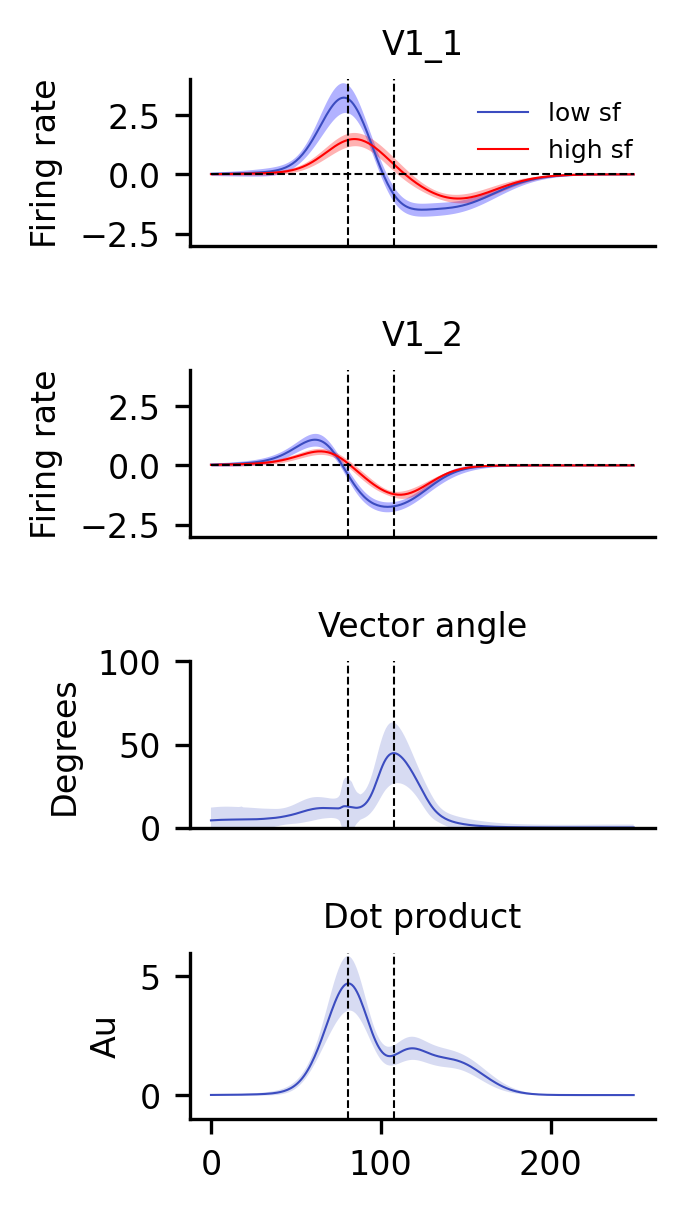

In [42]:
fig, ax = plt.subplots(4, figsize = (2,4.5))

titles = ['V1_1', 'V1_2']
for i in range(2):
    ax[i].plot(R[:,i,0,:].mean(0), label = 'low sf', linewidth = linewidth)
    ax[i].fill_between(
        np.arange(250),
        R[:,i,0,:].mean(0) + R[:,i,0,:].std(0),
        R[:,i,0,:].mean(0) - R[:,i,0,:].std(0),
        R[:,i,0,:].mean(0),
        linewidth=0,
        color = 'blue', alpha = 0.3
    )

    ax[i].plot(R[:,i,-1,:].mean(0), color = 'red', label = 'high sf', linewidth = linewidth)
    ax[i].fill_between(
        np.arange(250),
        R[:,i,-1,:].mean(0) + R[:,i,-1,:].std(0),
        R[:,i,-1,:].mean(0) - R[:,i,-1,:].std(0),
        R[:,i,-1,:].mean(0),
        linewidth=0,
        color = 'red', alpha = 0.3
    )

    ax[i].plot([t0]*250, np.linspace(-3,4,250), '--', color = 'black', linewidth = linewidth)
    ax[i].plot([t1]*250, np.linspace(-3,4,250), '--', color = 'black', linewidth = linewidth)
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].set_ylim(-3, 4)
    ax[i].set_ylabel("Firing rate", fontsize = fontsize)
    ax[i].set_title(titles[i], fontsize = fontsize)
ax[0].legend(fontsize = 6, frameon = False)


for i in range(4):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    if i < 3:
        ax[i].set_xticks([])


ax[2].plot(np.degrees(ang).mean(0), linewidth = linewidth)
ax[2].fill_between(
    np.arange(250),
    np.degrees(ang).mean(0)+np.degrees(ang).std(0),
    np.degrees(ang).mean(0)-np.degrees(ang).std(0),
    np.degrees(ang).mean(0), alpha = 0.2,
)
ax[2].plot([t0]*250, np.linspace(0,100,250), '--', color = 'black', linewidth = linewidth)
ax[2].plot([t1]*250, np.linspace(0,100,250), '--', color = 'black', linewidth = linewidth)
ax[2].set_ylim(0, 100)
ax[2].set_title("Vector angle", fontsize = fontsize)
ax[2].set_ylabel("Degrees", fontsize = fontsize)

ax[3].plot(dotprod.mean(0), linewidth = linewidth)
ax[3].fill_between(
    np.arange(250),
    dotprod.mean(0)+dotprod.std(0),
    dotprod.mean(0)-dotprod.std(0),
    dotprod.mean(0), alpha = 0.2,
)
ax[3].plot([t0]*250, np.linspace(-1,6,250), '--', color = 'black', linewidth = linewidth)
ax[3].plot([t1]*250, np.linspace(-1,6,250), '--', color = 'black', linewidth = linewidth)
ax[3].set_ylim(-1, 6)
ax[3].set_title("Dot product", fontsize = fontsize)
ax[3].set_ylabel("Au", fontsize = fontsize)
fig.subplots_adjust(hspace=0.75)

# figname = 'decorrelation_analysis_geometric_characterization_frozen_fts.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

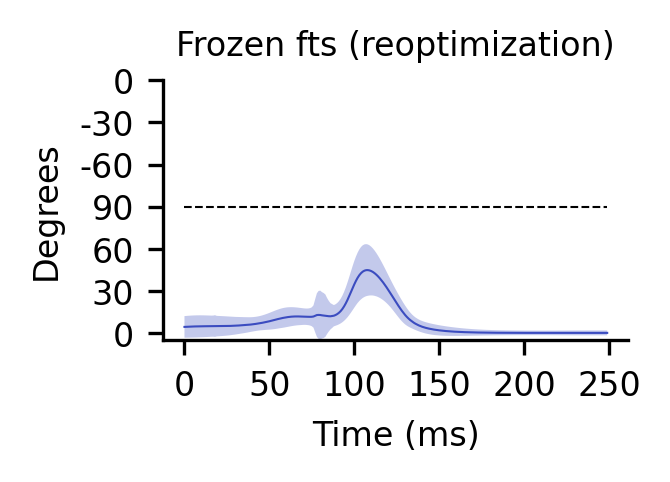

In [43]:
fig, ax = plt.subplots(1, figsize = (2,1.125))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_ylim(-5,180)
ax.set_yticks(np.arange(0,210,30))
ax.set_yticklabels(np.append(np.arange(0, 120, 30), np.arange(-60, 30, 30)))
ax.plot(np.arange(250), [90]*250, '--', color = 'black', linewidth = linewidth)
ax.plot(np.degrees(ang.mean(0)), linewidth = linewidth)
ax.fill_between(
    np.arange(250),
    np.degrees(ang.mean(0)) + np.degrees(ang.std(0)),
    np.degrees(ang.mean(0)) - np.degrees(ang.std(0)),
    np.degrees(ang.mean(0)), alpha = 0.3
)
ax.set_title("Frozen fts (reoptimization)", fontsize = fontsize)
ax.set_xticks(np.arange(0,300,50))
ax.set_ylabel("Degrees", fontsize = fontsize)
ax.set_xlabel("Time (ms)", fontsize = fontsize)
figname = f'ablation_analysis_angsep_v_dESI_frozen_fts.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
        bbox_inches = 'tight', dpi = 300)

In [18]:
import numpy as np

def curved_wedge(v1, v2):
    r = np.linalg.norm((v1 + v2) / 2)

    # angles
    theta1 = np.arctan2(v1[1], v1[0])
    theta2 = np.arctan2(v2[1], v2[0])

    # ensure shortest angular path
    dtheta = theta2 - theta1
    if dtheta > np.pi:
        theta2 -= 2*np.pi
    elif dtheta < -np.pi:
        theta2 += 2*np.pi

    # interpolate arc
    theta = np.linspace(theta1, theta2, 100)

    arc_x = r * np.cos(theta)
    arc_y = r * np.sin(theta)

    # build polygon: origin → arc → back to origin
    x = np.concatenate([[0], arc_x, [0]])
    y = np.concatenate([[0], arc_y, [0]])
    return x, y

In [19]:
def vector_uncertainty_span(
        samples, # for a set of 2D vectors (n_samp, xy)
):  
    # the vector perpendicular to the mean of the samples
    perp = np.array(
        [-samples.mean(0)[1], samples.mean(0)[0]]
    )

    # normalized perp
    unit_perp = perp/np.linalg.norm(perp)

    # rotate the samples
    projections = samples @ unit_perp

    # the scaling factor for the rotated samples
    s = projections.std()

    upper, lower = samples.mean(0) + unit_perp*s, samples.mean(0)-unit_perp*s

    return lower, samples.mean(0), upper

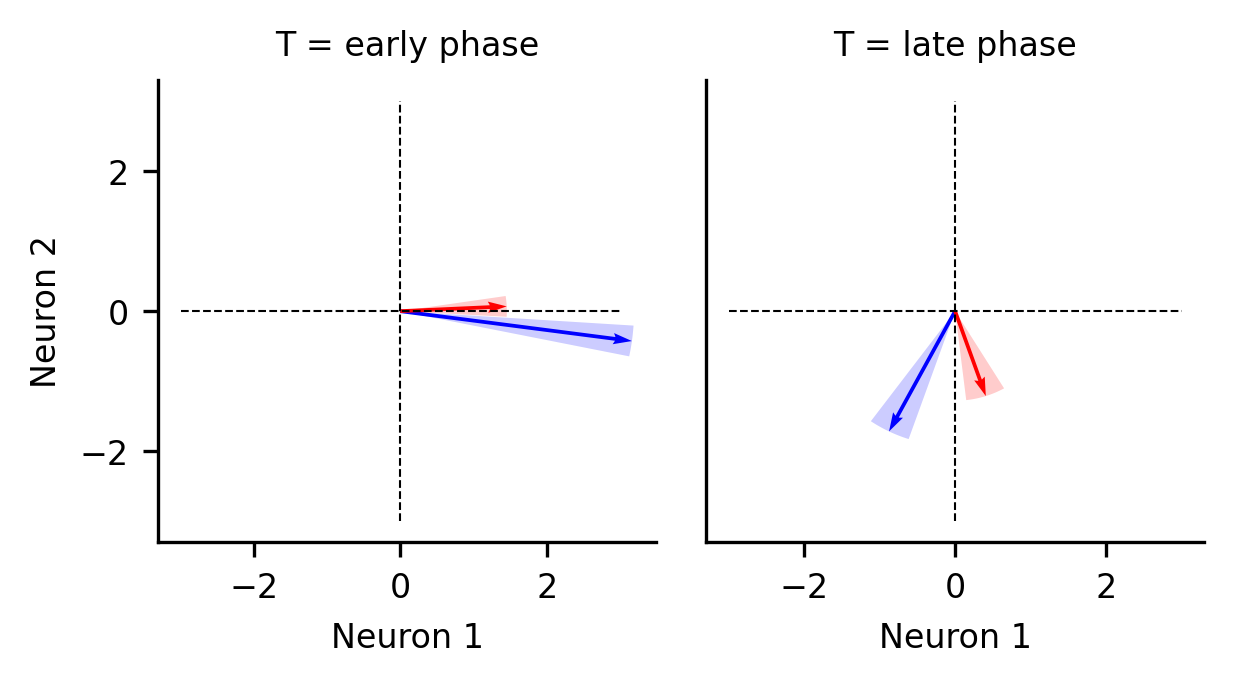

In [20]:
fig, ax = plt.subplots(1,2, figsize = (4.5,2))

high_sf_1 = R[:, :, -1]
high_sf_2 = R[:, 1, -1]

for i, t in enumerate([t0, t1]):
    low_sf = R[:, :, 0, t]
    high_sf = R[:, :, -1, t]
    
    lower_l, mean_l, upper_l = vector_uncertainty_span(low_sf)
    lower_l, upper_l = curved_wedge(lower_l, upper_l)
    
    lower_h, mean_h, upper_h = vector_uncertainty_span(high_sf)
    lower_h, upper_h = curved_wedge(lower_h, upper_h)

    scale = 1
    ax[i].quiver(
        0,0, 
        *mean_l, 
        scale = scale, color = 'blue',
        angles='xy',
        scale_units='xy',
    )
    ax[i].fill(
        lower_l, upper_l,
        color = 'blue',
         edgecolor='none',
         alpha = 0.2
    )
    
    ax[i].quiver(
        0,0, 
        *mean_h, 
        scale = scale, color = 'red',
        angles='xy',
        scale_units='xy',

    )
    ax[i].fill(
        lower_h, upper_h,
        color = 'red',
         edgecolor='none',
         alpha = 0.2
    )

for i in range(2):
    
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

    ax[i].plot([0]*250, np.linspace(-3, 3, 250), '--', color = 'black', linewidth = linewidth)
    ax[i].plot(np.linspace(-3, 3, 250), [0]*250, '--', color = 'black', linewidth = linewidth)
    ax[i].set_xlabel('Neuron 1', fontsize = fontsize)

ax[0].set_ylabel('Neuron 2', fontsize = fontsize)
ax[1].set_yticks([])
ax[0].set_title("T = early phase", fontsize = fontsize)
ax[1].set_title("T = late phase", fontsize = fontsize)
fig.subplots_adjust(wspace=0.1)

# figname = 'decorrelation_analysis_geometric_characterization_2vector_horiz_frozen_fts.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

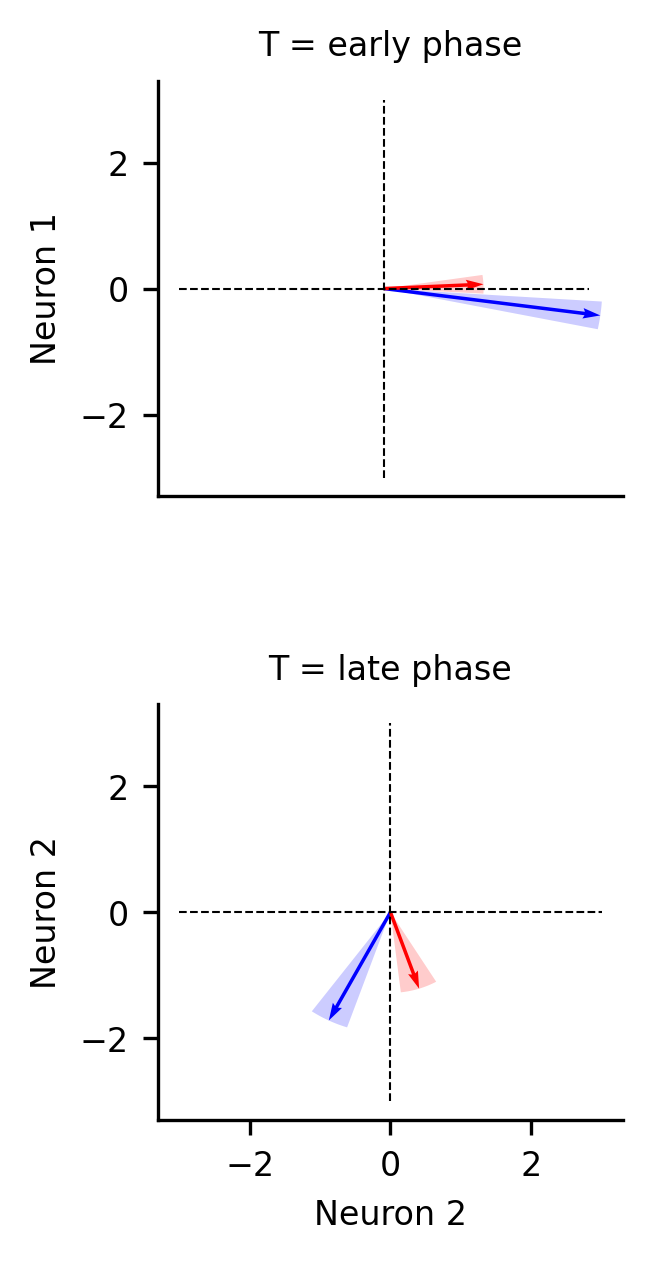

In [21]:
fig, ax = plt.subplots(2,1, figsize = (2, 4.5))

for i, t in enumerate([t0, t1]):
    low_sf = R[:, :, 0, t]
    high_sf = R[:, :, -1, t]
    
    lower_l, mean_l, upper_l = vector_uncertainty_span(low_sf)
    lower_l, upper_l = curved_wedge(lower_l, upper_l)
    
    lower_h, mean_h, upper_h = vector_uncertainty_span(high_sf)
    lower_h, upper_h = curved_wedge(lower_h, upper_h)

    scale = 1
    ax[i].quiver(
        0,0, 
        *mean_l, 
        scale = scale, color = 'blue',
        angles='xy',
        scale_units='xy',
    )
    ax[i].fill(
        lower_l, upper_l,
        color = 'blue',
         edgecolor='none',
         alpha = 0.2
    )
    
    ax[i].quiver(
        0,0, 
        *mean_h, 
        scale = scale, color = 'red',
        angles='xy',
        scale_units='xy',

    )
    ax[i].fill(
        lower_h, upper_h,
        color = 'red',
         edgecolor='none',
         alpha = 0.2
    )

for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].plot([0]*250, np.linspace(-3, 3, 250), '--', color = 'black', linewidth = linewidth)
    ax[i].plot(np.linspace(-3, 3, 250), [0]*250, '--', color = 'black', linewidth = linewidth)
    ax[i].set_ylabel('Neuron 1', fontsize = fontsize)

ax[1].set_xlabel('Neuron 2', fontsize = fontsize)
ax[1].set_ylabel('Neuron 2', fontsize = fontsize)
ax[0].set_xticks([])
ax[0].set_title("T = early phase", fontsize = fontsize)
ax[1].set_title("T = late phase", fontsize = fontsize)
fig.subplots_adjust(hspace=0.5)

# figname = 'decorrelation_analysis_geometric_characterization_2vector_vert_frozen_fts.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [22]:
from itertools import combinations
from scipy import stats

In [23]:
def pairwise_vector_comp(population_resp, sfs, diff='abs'):
    sf_combos = list(combinations(sfs, 2)) # list of comparisons of each unique SF condition
    sf_combo_idx = np.array(list(combinations(np.arange(len(sfs)),2))) # index wise comparisons of the SF conditions
    sf_octave_diff = np.array([np.log2(x[1]/x[0]) for x in sf_combos]) # octave difference of each SF comparison
    sf_abs_diff = np.array([np.abs(x[1]-x[0]) for x in sf_combos]) # octave difference of each SF comparison

    switch = {
        'oct': sf_octave_diff,
        'abs': sf_abs_diff
    }
    sf_diff_idx = np.argsort(switch[diff]) # combo index sorted from lowest to highest octave difference

    dotprod, ang = reduce_angle(
        population_resp[:,:,sf_combo_idx[:,0],:],
        population_resp[:,:,sf_combo_idx[:,1],:]
    )
    labels = switch[diff][sf_diff_idx]
    return ang[:,sf_diff_idx], dotprod[:,sf_diff_idx], labels

def calculate_sign_sum(X, unit_ax = 1):
    ## Calculate enhancement and suppression sums over time
    exc = np.sum(np.clip(X, 0, None), axis = unit_ax)
    sum = np.sum(np.clip(X, None, 0), axis = unit_ax)
                
    return exc, sum

def calculate_esi(exc, sup):
    return (
        (exc - np.abs(sup))
        / (np.abs(sup) + exc)
    ) 

def calculate_desi(esi, sfs, diff = 'abs', return_average = True):
    sf_combos = list(combinations(sfs, 2)) # list of comparisons of each unique SF condition
    sf_combo_idx = np.array(list(combinations(np.arange(len(sfs)),2))) # index wise comparisons of the SF conditions
    sf_octave_diff = np.array([np.log2(x[1]/x[0]) for x in sf_combos]) # octave difference of each SF comparison
    sf_abs_diff = np.array([np.abs(x[1]-x[0]) for x in sf_combos]) # octave difference of each SF comparison

    switch = {
        'oct': sf_octave_diff,
        'abs': sf_abs_diff
    }
    sf_diff_idx = np.argsort(switch[diff]) # combo index sorted from lowest to highest octave difference
    
    desi = np.abs(
        (esi[:,sf_combo_idx[:,0],:]
         -esi[:,sf_combo_idx[:,1],:])
    )
    
    return desi[:,sf_diff_idx,:]

In [24]:
ang, dp, labels = pairwise_vector_comp(R,X)
exc, sup = calculate_sign_sum(R)
esi = calculate_esi(exc, sup)
desi = calculate_desi(esi, X)

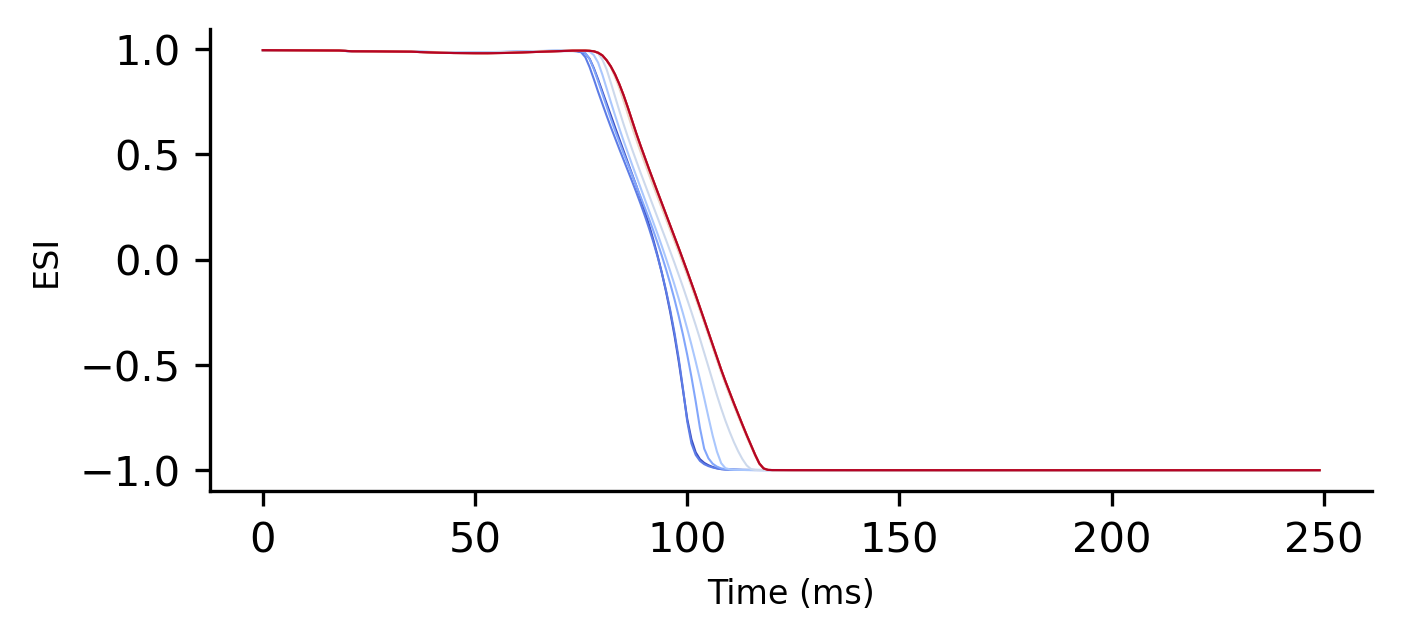

In [ ]:
fongsize = 6
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(figsize = (5,2))
ax.plot(esi.mean(0).T, linewidth = linewidth)
ax.set_ylabel("ESI", fontsize = fontsize)
ax.set_xlabel("Time (ms)", fontsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax2 = fig.add_axes([0.2, 0.4, 0.15, 0.2])
# ax2.plot(exc.mean(0)[:,:5].T, linewidth = linewidth)
# ax2.set_title('ENH (first 5ms)', fontsize = fontsize)
# ax3 = fig.add_axes([0.675, 0.4, 0.15, 0.2])
# ax3.plot(sup.mean(0)[:,-5:].T, linewidth = linewidth)
# ax3.set_title('SUP (last 5ms)', fontsize = fontsize)

# for ax in [ax2, ax3]:
#     ax.tick_params(labelsize = 5, rotation = 0)
#     #ax.set_ylim(-0.0017,0.0017)
#     ax.plot(np.zeros(5), '--', color = 'black', linewidth = linewidth)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# figname = 'decorrelation_analysis_esi_progression_frozen_fts.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.0, 'SF vector dESI')

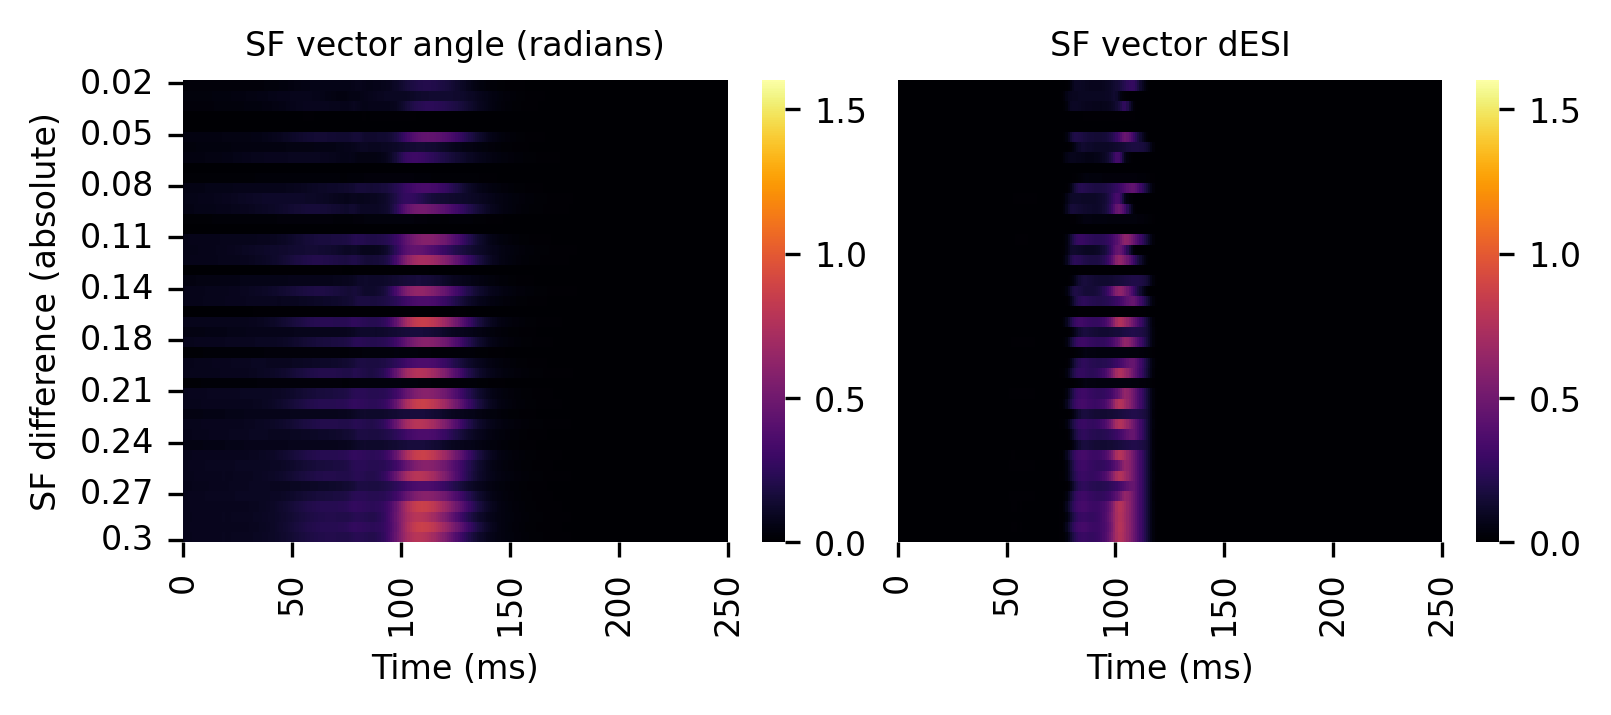

In [25]:
fig, ax = plt.subplots(1,2, figsize = (6, 2))

cmap = 'inferno'
sns.heatmap(
    ang.mean(0), ax = ax[0], 
    cmap = cmap, vmin = 0, vmax = 1.6
)
sns.heatmap(
    desi.mean(0), ax = ax[1], 
    cmap = cmap, vmin = 0, vmax = 1.6
)

for i in range(2):
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xticks(np.arange(0,300,50))
    ax[i].set_xticklabels(np.arange(0,300,50))
    ax[i].collections[0].colorbar.ax.tick_params(labelsize = fontsize)

plt.subplots_adjust(wspace = 0.05)
ticks = np.arange(0.3,45.5,5)
ticks[-1]-=0.5
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(np.linspace(labels[0], labels[-1], 10).round(2))
ax[0].set_ylabel("SF difference (absolute)", fontsize = fontsize)
ax[1].set_yticks([])
ax[0].set_title("SF vector angle (radians)", fontsize = fontsize)
ax[1].set_title("SF vector dESI", fontsize = fontsize)

# figname = 'decorrelation_analysis_angsep_v_dESI_frozen_fts.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [26]:
from scipy.stats import ttest_rel

In [27]:
## Credit goes to skynaut (2015) on Stackoverflow: https://stackoverflow.com/questions/21532471/how-to-calculate-cohens-d-in-python
def cohensd(x,y):
    if len(x) == len(y):
        return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1) ** 2 + np.std(y, ddof=1) ** 2) / 2.0)
    else:
        nx = len(x)
        ny = len(y)
        dof = nx + ny - 2
        return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

In [28]:
ttest_rel(
    np.argmax(desi.mean(1), axis = 1),
    np.argmax(ang.mean(1), axis = 1)
)

TtestResult(statistic=-11.173878022091941, pvalue=2.132379290346271e-27, df=999)

In [29]:
cohensd(
    np.argmax(desi.mean(1), axis = 1),
    np.argmax(ang.mean(1), axis = 1)
)

-0.41724562116070324

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_52052\891585077.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr = np.round(np.nanmean([pearsonr(np.squeeze(desi[n,:,dmax]), ang[n,:,t1])[0] for n in range(1000)]), 2)


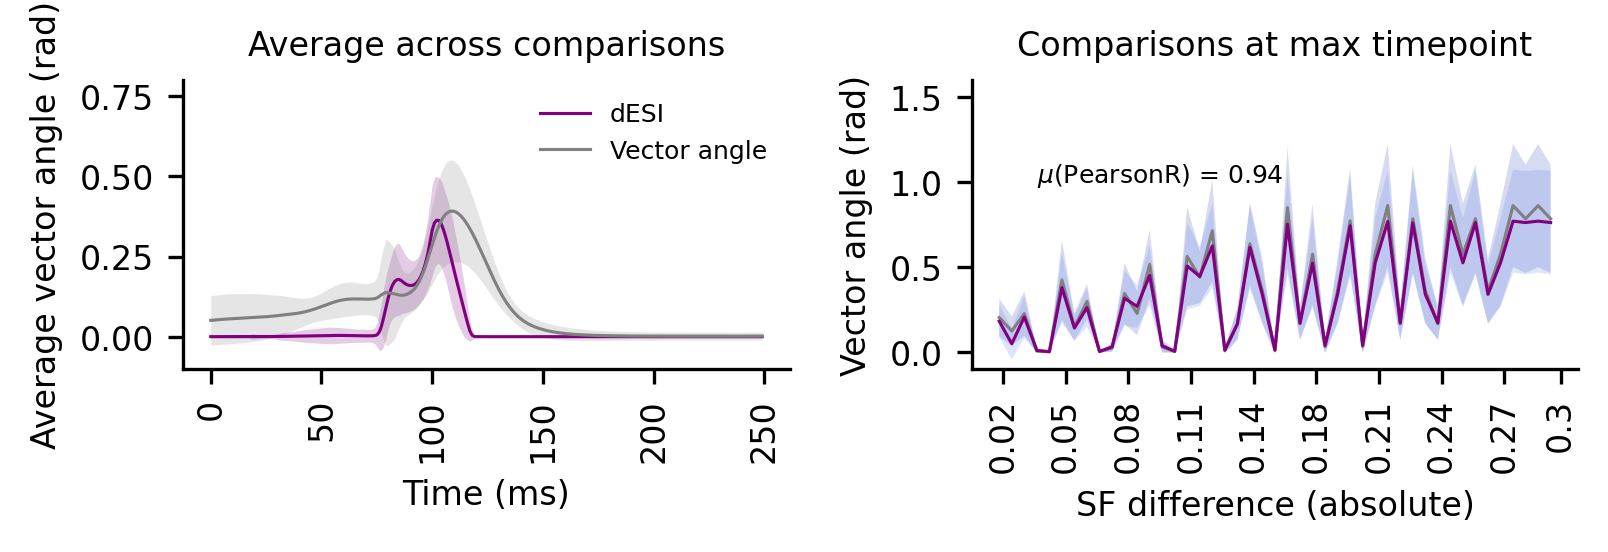

In [30]:
linewidth = 0.75
fig, ax = plt.subplots(1,2, figsize = (6,1.25))
ax[0].plot(desi.mean((0,1)), color = 'purple', label = 'dESI', linewidth = linewidth)
ax[0].fill_between(
    np.arange(250),
    desi.mean((0,1)) + desi.mean(1).std(0), 
    desi.mean((0,1)) - desi.mean(1).std(0),
    desi.mean((0,1)),
    color = 'purple',
    alpha = 0.2,
    linewidth = 0
)

ax[0].plot(ang.mean((0,1)), color = 'gray', label = 'Vector angle', linewidth = linewidth)
ax[0].fill_between(
    np.arange(250),
    ang.mean((0,1)) + ang.mean(1).std(0), 
    ang.mean((0,1)) - ang.mean(1).std(0),
    ang.mean((0,1)),
    color = 'gray',
    alpha = 0.2,
    linewidth = 0
)

ax[0].set_xlabel("Time (ms)", fontsize = fontsize)
ax[0].set_title("Average across comparisons", fontsize = fontsize)
ax[0].set_xticks(np.arange(0,300,50))
ax[0].set_xticklabels(np.arange(0,300,50), rotation = 90)
dmax = np.where(desi.mean((0,1)) == desi.mean((0,1)).max())[0]

pr = np.round(np.nanmean([pearsonr(np.squeeze(desi[n,:,dmax]), ang[n,:,t1])[0] for n in range(1000)]), 2)
ax[1].text(3, 1, f"$\mu$(PearsonR) = {pr}", fontsize = 6)
ax[1].plot(ang.mean(0)[:,t1], '-', color = 'gray', linewidth = linewidth)
ax[1].fill_between(
    np.arange(45),
    ang.mean(0)[:,t1] + ang.std(0)[:,t1],
    ang.mean(0)[:,t1] - ang.std(0)[:,t1],
    ang.mean(0)[:,t1],
    'gray', alpha = 0.2
)

ax[1].plot(desi.mean(0)[:,dmax], '-', color = 'purple', linewidth = linewidth)
ax[1].fill_between(
    np.arange(45),
    np.squeeze(desi.mean(0)[:,dmax] + desi.std(0)[:,dmax]),
    np.squeeze(desi.mean(0)[:,dmax] - desi.std(0)[:,dmax]),
    np.squeeze(desi.mean(0)[:,dmax]),
    'purple', alpha = 0.2
)

ax[1].set_xticks(np.arange(0,50,5))
ax[1].set_xlabel("SF difference (absolute)", fontsize = fontsize)
ax[1].set_title("Comparisons at max timepoint", fontsize = fontsize)
ticks = np.arange(0.3,45.5,5)
ticks[-1]-=0.5
ax[1].set_xticks(ticks)
ax[1].set_xticklabels(np.linspace(labels[0], labels[-1], 10).round(2), rotation = 90)

ylabels = ['Average vector angle (rad)', 'Vector angle (rad)']
upperlims = [0.8, 1.6]
for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_ylabel(ylabels[i], fontsize = fontsize)
    ax[i].set_ylim(-0.1,upperlims[i])

fig.subplots_adjust(wspace=0.3)
ax[0].legend(fontsize = 6, loc = 'upper right', frameon=False)

# figname = 'decorrelation_analysis_angsep_v_dESI_avg_&_max_frozen_fts.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [31]:
msd = (((np.squeeze(desi[:,:,dmax]) - ang[:,:,t1])**2).mean(1))

In [32]:
last_epoch[np.where(msd == msd.max())[0][0]]

0.136

Text(0, 0.5, 'Loss')

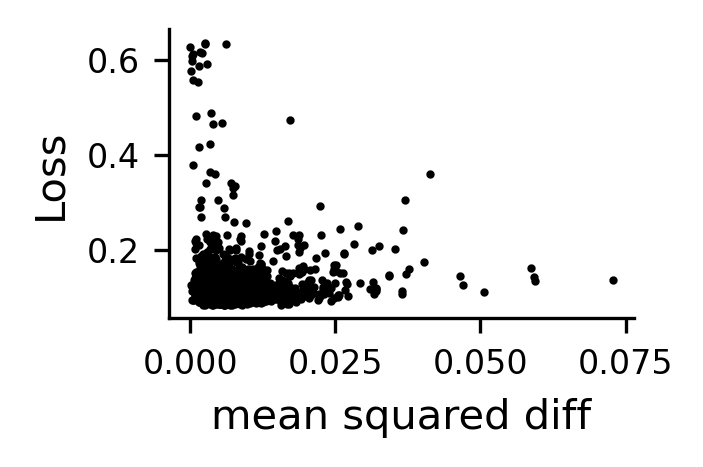

In [33]:
fig, ax = plt.subplots(1, figsize = (2,1.25))
ax.scatter(msd, last_epoch, s=1, color = 'black')

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('mean squared diff')
ax.set_ylabel('Loss')

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_52052\858018004.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(desi.mean(0)[i, dmax], ang.mean(0)[i,t1], c=cmap(c_index[c]), s=10)


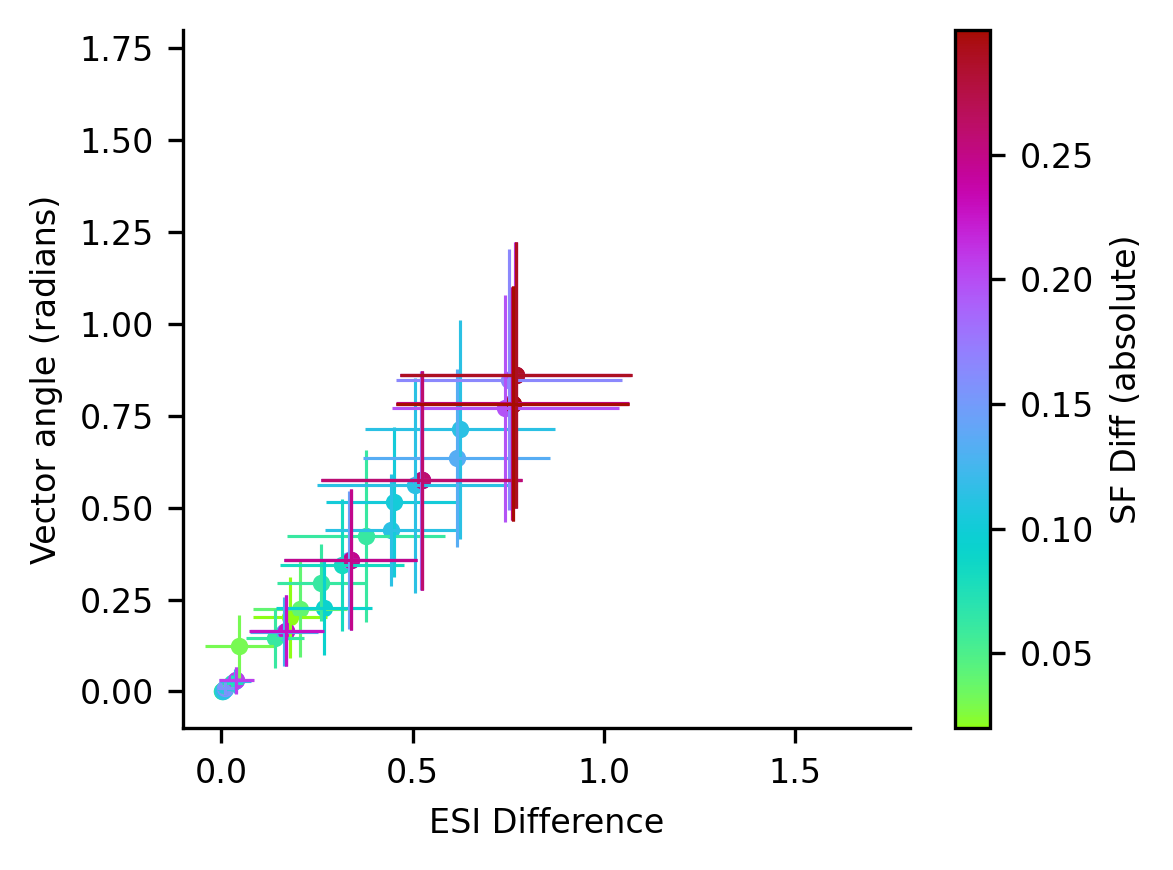

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable


sf_diff_unique = sorted(np.unique(labels))
scales = np.linspace(min(sf_diff_unique), max(sf_diff_unique), 6).round(2)
norm = plt.Normalize(min(sf_diff_unique), max(sf_diff_unique))
cmap = plt.get_cmap('cmr.neon_r')

fig, ax = plt.subplots(figsize=(4, 3))

c_index = np.linspace(0, 1, 28)

for i, diff in enumerate(labels):
    c = sf_diff_unique.index(diff) 
    ax.scatter(desi.mean(0)[i, dmax], ang.mean(0)[i,t1], c=cmap(c_index[c]), s=10)
    ax.errorbar(
        desi.mean(0)[i, dmax], 
        ang.mean(0)[i,t1], 
        yerr=ang.std(0)[i,t1], 
        c=cmap(c_index[c]),
        elinewidth = 0.75,
    )
    ax.errorbar(
        desi.mean(0)[i, dmax], 
        ang.mean(0)[i,t1], 
        xerr=desi.std(0)[i, dmax], 
        c=cmap(c_index[c]),
        elinewidth = 0.75,
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=fontsize)
ax.set_xlabel("ESI Difference", fontsize=fontsize)
ax.set_ylabel("Vector angle (radians)", fontsize=fontsize)
ax.set_ylim(-0.1,1.8)
ax.set_xlim(-0.1,1.8)

sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label("SF Diff (absolute)", fontsize=fontsize)

plt.tight_layout()

figname = 'angle_v_dESI_v_SFdiff_gayplot_frozen_fts.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)